# Heat Sink Thermal Model ,Parameter Sweep + ML Surrogate

Task 1: modified heat sink model, parameter sweep to CSV,
ML surrogate models with accuracy comparison, correlation/sensitivity
analysis.



In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

pd.set_option("display.max_columns", None)
%matplotlib inline


## 1. Model

Kept all the geometry/TIM/die constants same as the base script, only
TDP, V_air and k_tim are variables now. R_jc = 0.2 

In [15]:
# geometry / constants - same as base script
L_die = 0.0525
W_die = 0.045
Thickness_die = 0.0022

L = 90e-3
W = 116e-3
H = 27e-3
Fin_Thickness = 0.8e-3
N_fins = 60
Base_Thickness = 2.5e-3
t_tim = 0.1e-3
R_jc = 0.2

# air props @ 25C
k_air = 0.0262
nu_air = 1.57e-5
Pr_air = 0.71


def heat_sink_design(TDP, V_air, k_tim, T_ambient=25.0):
    s_f = (W - (N_fins * Fin_Thickness)) / (N_fins - 1)
    Re = (V_air * s_f) / nu_air

    if Re < 2300:
        Nu = 1.86 * ((Re * Pr_air * (2 * s_f) / L) ** (1 / 3))
        flow_regime = "laminar"
    else:
        Nu = 0.023 * (Re ** 0.8) * (Pr_air ** 0.3)
        flow_regime = "turbulent"

    h_conv = (Nu * k_air) / (2 * s_f)
    h_fin = H - Base_Thickness

    A_fin = N_fins * (2 * h_fin * L) + (s_f * L)
    A_Total_base = L * W
    A_base_convection = A_Total_base - (Fin_Thickness * N_fins * L)
    A_total = A_fin + A_base_convection

    R_conv = 1 / (h_conv * A_total)

    A_die = L_die * W_die
    R_tim = t_tim / (k_tim * A_die)

    R_hs = R_conv + R_tim
    R_total = R_jc + R_hs
    T_j = T_ambient + (TDP * R_total)

    return {
        "TDP": TDP, "V_air": V_air, "k_tim": k_tim, "T_ambient": T_ambient,
        "s_f": s_f, "Re": Re, "Nu": Nu, "h_conv": h_conv,
        "flow_regime": flow_regime, "A_fin": A_fin,
        "A_base_convection": A_base_convection, "A_total": A_total,
        "R_conv": R_conv, "R_tim": R_tim, "R_hs": R_hs,
        "R_total": R_total, "T_j": T_j,
    }


In [17]:
# check against the base script's default point (TDP=150, V_air=1, k_tim=4)
# should get R_total ~0.3, T_j ~80.4
baseline = heat_sink_design(TDP=150, V_air=1, k_tim=4.0, T_ambient=25)
print(baseline["R_total"], baseline["T_j"])


0.3692049352073151 80.38074028109727


## 2. Parameter sweep

Ranges as given in the task: TDP 30-250 W, V_air 0.5-15 m/s, k_tim
1-12 W/mK. Went with a grid instead of random sampling mainly so it's
reproducible and I could control resolution on V_air (wanted enough
points to see if it ever crosses into turbulent flow, Re=2300).

25 x 30 x 12 = 9000 rows.


In [18]:
tdp_vals = np.linspace(30, 250, 25)
vair_vals = np.linspace(0.5, 15, 30)
ktim_vals = np.linspace(1, 12, 12)

rows = []
for tdp in tdp_vals:
    for vair in vair_vals:
        for ktim in ktim_vals:
            rows.append(heat_sink_design(TDP=tdp, V_air=vair, k_tim=ktim, T_ambient=25.0))

df = pd.DataFrame(rows)
cols = ["TDP", "V_air", "k_tim", "T_ambient", "s_f", "Re", "Nu", "h_conv",
        "flow_regime", "A_fin", "A_base_convection", "A_total",
        "R_conv", "R_tim", "R_hs", "R_total", "T_j"]
df = df[cols]

print(len(df), "rows")
df["flow_regime"].value_counts()


9000 rows


flow_regime
laminar    9000
Name: count, dtype: int64

In [19]:
df.to_csv("heat_sink_sweep_dataset.csv", index=False)
df.head()


,TDP,V_air,k_tim,T_ambient,s_f,Re,Nu,h_conv,flow_regime,A_fin,A_base_convection,A_total,R_conv,R_tim,R_hs,R_total,T_j
0,30.0,0.5,1.0,25.0,0.001153,36.705171,1.62551,18.475832,laminar,0.264704,0.00612,0.270824,0.199852,0.042328,0.242180,0.442180,38.265412
1,30.0,0.5,2.0,25.0,0.001153,36.705171,1.62551,18.475832,laminar,0.264704,0.00612,0.270824,0.199852,0.021164,0.221016,0.421016,37.630491
2,30.0,0.5,3.0,25.0,0.001153,36.705171,1.62551,18.475832,laminar,0.264704,0.00612,0.270824,0.199852,0.014109,0.213962,0.413962,37.418851
3,30.0,0.5,4.0,25.0,0.001153,36.705171,1.62551,18.475832,laminar,0.264704,0.00612,0.270824,0.199852,0.010582,0.210434,0.410434,37.313031
4,30.0,0.5,5.0,25.0,0.001153,36.705171,1.62551,18.475832,laminar,0.264704,0.00612,0.270824,0.199852,0.008466,0.208318,0.408318,37.249539


Turns out every single row is laminar . fin spacing here is small
enough ( arounnd 1.15mm) that even at 15 m/s, Re only gets to  soemthing around 1100, still under 2300
. So the turbulent branch of the model never actually gets used in
this dataset. Kept it in mind as a limitation later, didn't want to
change the given V_air range since the task specifies 0.5-15.


## 3. ML surrogate models

Predicting R_total and T_j from (TDP, V_air, k_tim). Using two models:

- Linear regression, but with degree-2 polynomial features. Plain linear
  regression underfits because of the 1/k_tim and Re^0.8 type terms in
  the physics, so added the polynomial expansion as a slightly better
  but still simple/interpretable baseline.
- Random Forest, since it should handle the nonlinearity without needing
  me to hand-pick feature transforms, and gives feature importances too.


In [20]:
FEATURES = ["TDP", "V_air", "k_tim"]
X = df[FEATURES].values
y_R = df["R_total"].values
y_T = df["T_j"].values

X_train, X_test, yR_train, yR_test, yT_train, yT_test = train_test_split(
    X, y_R, y_T, test_size=0.2, random_state=42
)

models = {
    "Linear Regression (poly deg2)": lambda: make_pipeline(
        PolynomialFeatures(degree=2, include_bias=False), LinearRegression()
    ),
    "Random Forest": lambda: RandomForestRegressor(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
}

results = []
fitted_rf = {}

for target, y_train, y_test in [("R_total", yR_train, yR_test), ("T_j", yT_train, yT_test)]:
    for name, make_model in models.items():
        m = make_model()
        m.fit(X_train, y_train)
        pred = m.predict(X_test)
        results.append({
            "Target": target, "Model": name,
            "MAE": mean_absolute_error(y_test, pred),
            "RMSE": np.sqrt(mean_squared_error(y_test, pred)),
            "R2": r2_score(y_test, pred),
        })
        if name == "Random Forest":
            fitted_rf[target] = m

results_df = pd.DataFrame(results)
results_df.to_csv("ml_model_accuracy_results.csv", index=False)
results_df


,Target,Model,MAE,RMSE,R2
0,R_total,Linear Regression (poly deg2),7.733499e-03,1.097348e-02,0.886667
1,R_total,Random Forest,1.028128e-15,1.195203e-15,1.000000
2,T_j,Linear Regression (poly deg2),1.339300e+00,2.030651e+00,0.990451
3,T_j,Random Forest,1.166065e-01,3.302720e-01,0.999747


Random Forest basically gets R2 = 1.0 on R_total which looked suspicious
to me at first. Dug into it a bit and fuund that 

 The dataset has zero noise, it's a plain formula, so there's nothing
  random for the model to memorize incorrectly.
 The 80/20 split is random points scattered across a pretty dense grid,
  so the test points are sitting right next to training points that
  weren't held out. That's an easy interpolation problem for a forest.

To actually stresstest it, I retrained on TDP < 200W only and tested on
TDP >= 200W - i.e. a range it never saw at all.


In [21]:
train = df[df["TDP"] < 200]
test = df[df["TDP"] >= 200]

extrap_results = []
for target in ["R_total", "T_j"]:
    m = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
    m.fit(train[FEATURES], train[target])
    pred = m.predict(test[FEATURES])
    extrap_results.append({
        "Target": target,
        "MAE": mean_absolute_error(test[target], pred),
        "RMSE": np.sqrt(mean_squared_error(test[target], pred)),
        "R2": r2_score(test[target], pred),
    })

extrap_df = pd.DataFrame(extrap_results)
extrap_df.to_csv("extrapolation_test_results.csv", index=False)
extrap_df


,Target,MAE,RMSE,R2
0,R_total,1.033741e-15,1.205315e-15,1.000000
1,T_j,9.695313e+00,1.085396e+01,-0.543213


R_total still comes out perfect here, which makes sense once you look at
the correlation numbers below .... it doesn't depend on TDP at all, so this
"extrapolation" test isn't really testing anything for that target.

T_j is the interesting one - R2 goes negative once TDP is outside the
range it trained on. So the forest interpolates great but can't
extrapolate, which is basically expected behavior for tree models but
good to actually confirm instead of assuming.


## 4. Correlation / sensitivity analysis


In [22]:
corr_cols = FEATURES + ["R_total", "T_j"]
corr_matrix = df[corr_cols].corr()
corr_matrix.to_csv("correlation_matrix.csv")
corr_matrix.round(3)



,TDP,V_air,k_tim,R_total,T_j
TDP,1.00,0.000,-0.000,0.000,0.970
V_air,0.00,1.000,0.000,-0.796,-0.175
k_tim,-0.00,0.000,1.000,-0.259,-0.057
R_total,0.00,-0.796,-0.259,1.000,0.220
T_j,0.97,-0.175,-0.057,0.220,1.000


## lets get graphical understading now

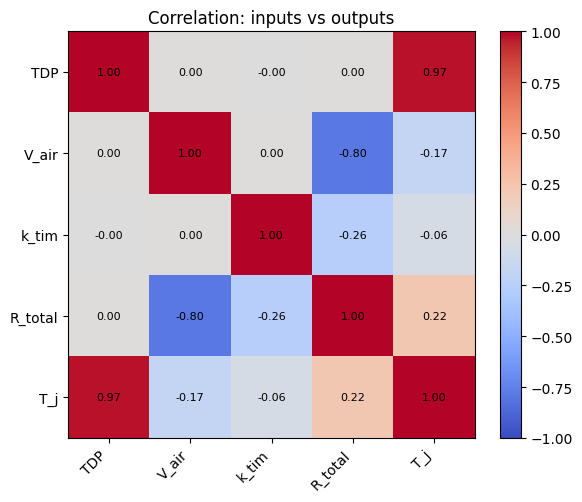

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr_matrix.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax)
ax.set_title("Correlation: inputs vs outputs")
fig.tight_layout()
fig.savefig("correlation_heatmap.png", dpi=150)
plt.show()


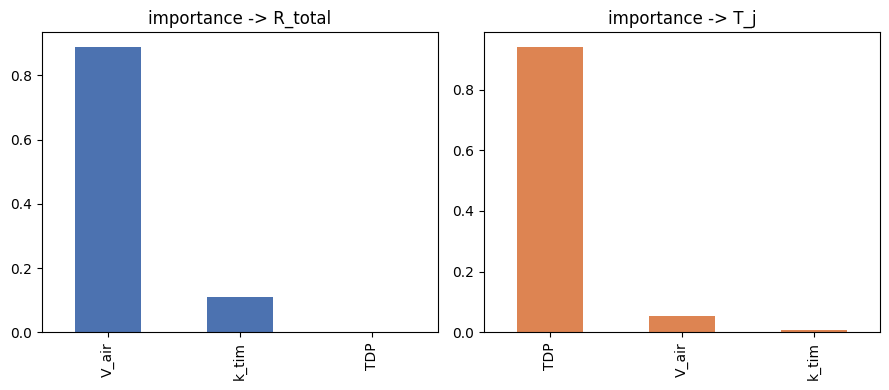

(V_air    8.898781e-01
 k_tim    1.101219e-01
 TDP      2.054003e-15
 dtype: float64,
 TDP      0.941617
 V_air    0.052154
 k_tim    0.006229
 dtype: float64)

In [24]:
imp_R = pd.Series(fitted_rf["R_total"].feature_importances_, index=FEATURES).sort_values(ascending=False)
imp_T = pd.Series(fitted_rf["T_j"].feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))
imp_R.plot(kind="bar", ax=axes[0], color="#4C72B0", title="importance -> R_total")
imp_T.plot(kind="bar", ax=axes[1], color="#DD8452", title="importance -> T_j")
fig.tight_layout()
fig.savefig("feature_importance.png", dpi=150)
plt.show()

imp_R, imp_T


So basically R_total is mostly a function of V_air (makes sense, it drives
the convection term), k_tim has a smaller effect. TDP has near to zero effect on
R_total since it literally isnt in that formula.

T_j on the other hand is almost entirely explained by TDP which
tracks, since T_j = T_ambient + TDP * R_total, and R_total only moves in
a fairly narrow band compared to how much TDP swings (30 to 250 W).
V_air and k_tim only affect T_j indirectly through R_total, so their
importance is much smaller here.


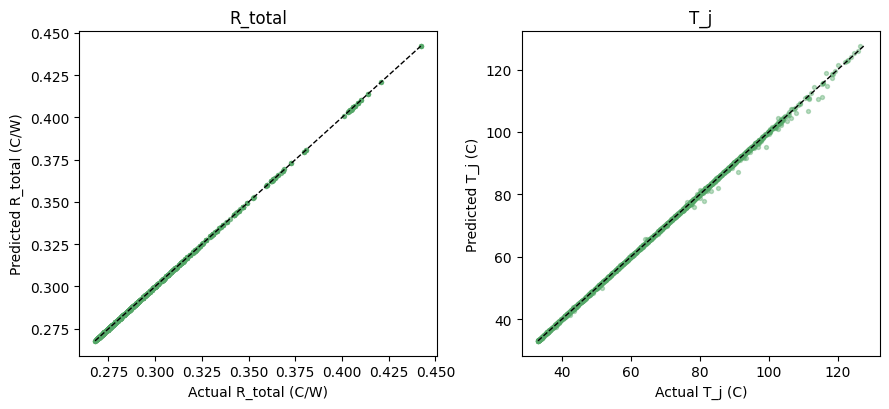

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4.2))
for ax, target, ylabel in zip(axes, ["R_total", "T_j"], ["R_total (C/W)", "T_j (C)"]):
    pred = fitted_rf[target].predict(X_test)
    true = yR_test if target == "R_total" else yT_test
    ax.scatter(true, pred, s=8, alpha=0.4, color="#55A868")
    lims = [min(true.min(), pred.min()), max(true.max(), pred.max())]
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlabel(f"Actual {ylabel}"); ax.set_ylabel(f"Predicted {ylabel}")
    ax.set_title(target)
fig.tight_layout()
fig.savefig("parity_plots_random_forest.png", dpi=150)
plt.show()


## 5. Notes and  limitations after doing this Assesement

1. Dataset is noise free (straight from the formula), so R2 numbers here
  are probably optimistic vs. what we would see against real measured data.
2) Turbulent branch of the model never gets triggered in this sweep range
  would need a smaller fin spacing or higher velocity to see it.
3) Only swept TDP/V_air/k_tim, geometry and R_jc stayed fixed, so this
  surrogate is specific to this one heat sink design.
4) RF surrogate is solid for interpolation within the swept range but
  shouldn't be trusted to extrapolate past it (confirmed above).


